In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [38]:
dataset = pd.read_csv("Data.csv")

x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [39]:
print(y)

<StringArray>
['No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes']
Length: 10, dtype: str


## Taking care of missing data

In [40]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

In [41]:
imputer.fit(x[:, 1:3])
x[:, 1:3] = imputer.transform(x[:, 1:3])

In [42]:
print(x)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 63777.77777777778]
 ['France' 35.0 58000.0]
 ['Spain' 38.77777777777778 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


### Encoding city column so that the model doesn't interpret as ordered value

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [44]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
output = ct.fit_transform(x)
x = np.array(output)
print(x)

[[1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [0.0 1.0 0.0 30.0 54000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 35.0 58000.0]
 [0.0 0.0 1.0 38.77777777777778 52000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


In [45]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y = le.fit_transform(y)
print(y)

[0 1 0 0 1 1 0 1 0 1]


### Splitting the data into training set and test set

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [47]:
print("X train")
print(X_train)
print("\n\nX Test")
print(X_test)
print("\n\nY train")
print(y_train)
print("\n\nY Test")
print(y_test)

X train
[[0.0 0.0 1.0 38.77777777777778 52000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 35.0 58000.0]]


X Test
[[0.0 1.0 0.0 30.0 54000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


Y train
[0 1 0 0 1 1 0 1]


Y Test
[0 1]


### Feature Scaling

To scale all input params into same range so that one variable doesn't domainate over other 

Ex : Area (sqft) is a smaller number than the price, so price will dominate without feature scaling

Don't do standardization on dummy features / categorical features

Standardisation 
- good for generic data sets or Gaussian distribution
- No fixed bound range

Normalization is 
- best where distribution of data in not Gaussian (Normal) 
- when you know the bounds of data (Highly sensitive to ourliers)

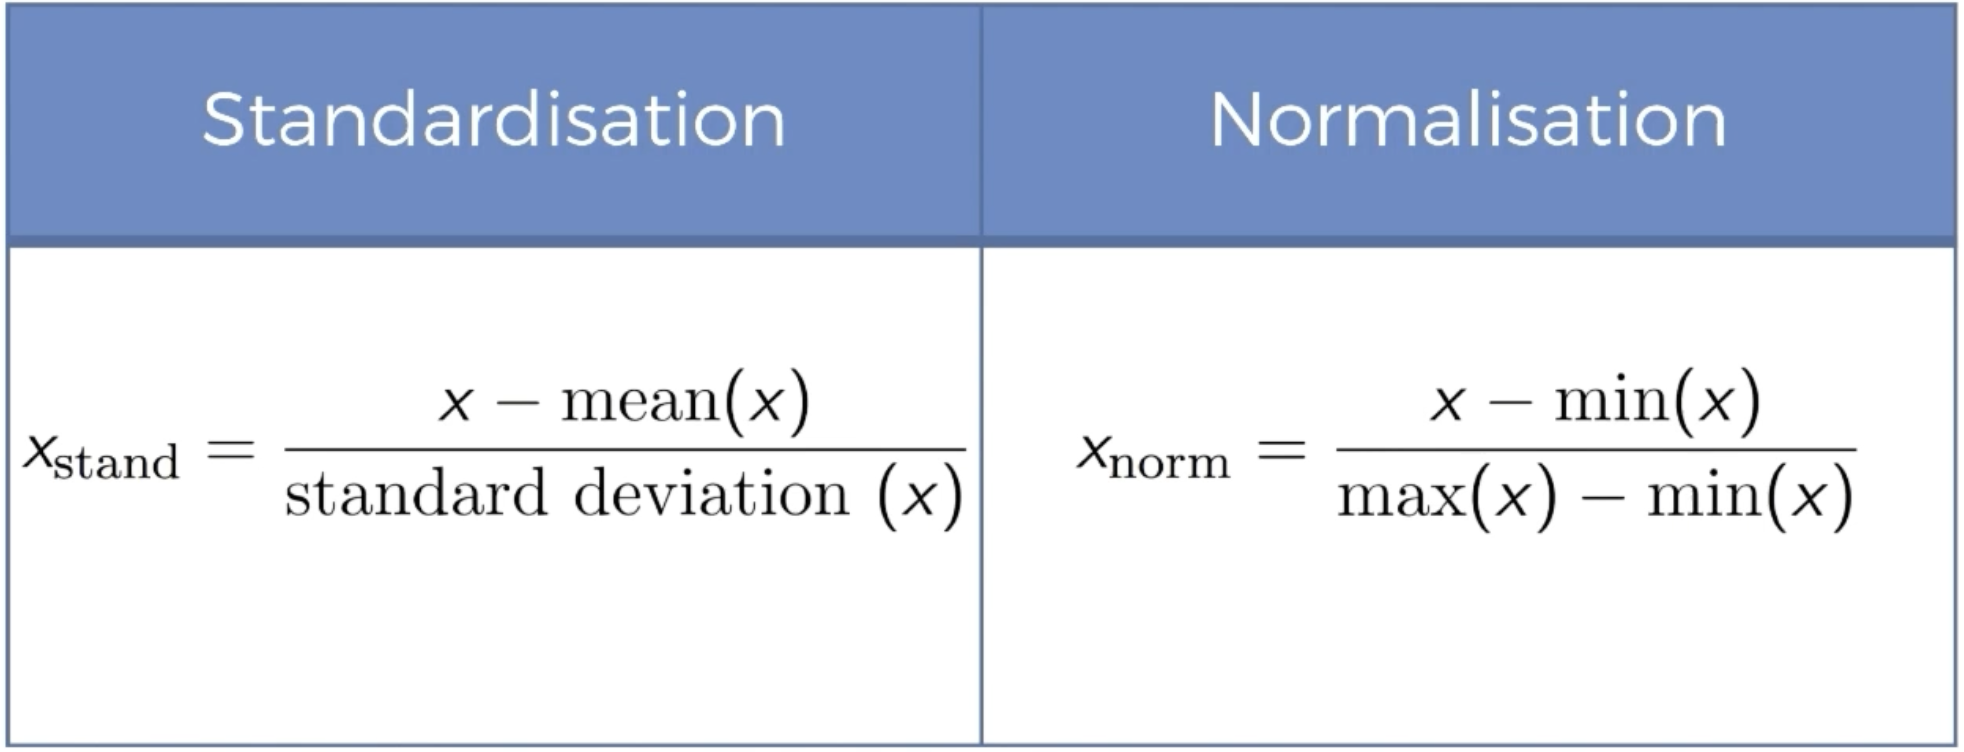
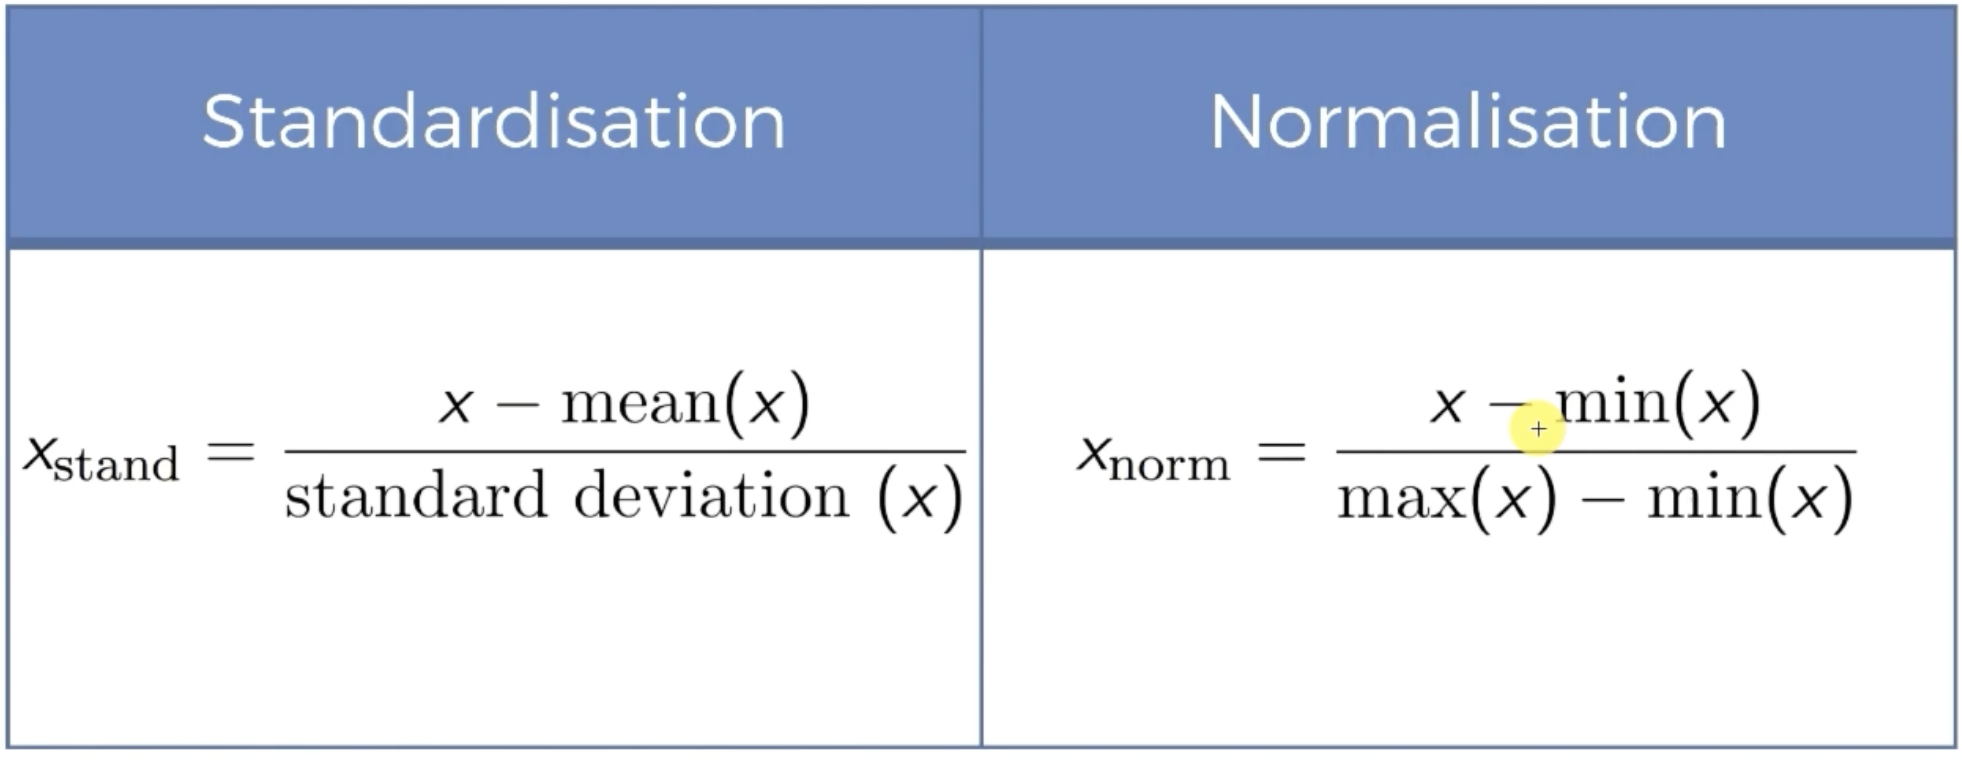

In [48]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train[:, 3:] = sc.fit_transform(X_train[:, 3:])

## Using the same params of previous fit_transform so that the test data can be fitted similarly 
X_test[:, 3:] = sc.transform(X_test[:, 3:])

In [50]:
print("X train")
print(X_train)
print("\n\nX test")
print(X_test)


X train
[[0.0 0.0 1.0 -0.19159184384578545 -1.0781259408412425]
 [0.0 1.0 0.0 -0.014117293757057777 -0.07013167641635372]
 [1.0 0.0 0.0 0.566708506533324 0.633562432710455]
 [0.0 0.0 1.0 -0.30453019390224867 -0.30786617274297867]
 [0.0 0.0 1.0 -1.9018011447007988 -1.420463615551582]
 [1.0 0.0 0.0 1.1475343068237058 1.232653363453549]
 [0.0 1.0 0.0 1.4379472069688968 1.5749910381638885]
 [1.0 0.0 0.0 -0.7401495441200351 -0.5646194287757332]]


X test
[[0.0 1.0 0.0 -1.4661817944830124 -0.9069571034860727]
 [1.0 0.0 0.0 -0.44973664397484414 0.2056403393225306]]
